In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import time
from collections import Counter
from sklearn.feature_extraction.text import CountVectorizer
import warnings 

In [4]:
# Suppress warnings for cleaner output
warnings.filterwarnings('ignore')

# Set aesthetic parameters for seaborn
sns.set_theme(style="whitegrid", palette="muted")

In [ ]:
# PATH SETUP
PATH = "../data/raw/dataset.csv"

## Load Data

Data Loading and basic Overview

In [12]:
start_time = time.time()
column_names = ['target', 'id', 'date', 'flag', 'user', 'text']
    
# latin-1 is strictly required for this dataset
df = pd.read_csv(PATH, encoding='latin-1', names=column_names)
    
print(f"Dataset loaded in {time.time() - start_time:.2f} seconds.")
print(f"Total Rows: {df.shape[0]:,}")
print(f"Total Columns: {df.shape[1]}")

Dataset loaded in 4.02 seconds.
Total Rows: 1,600,000
Total Columns: 6


In [13]:
# missing value analysis
df.isnull().sum()

target    0
id        0
date      0
flag      0
user      0
text      0
dtype: int64

In [14]:
# data types
df.dtypes

target     int64
id         int64
date      object
flag      object
user      object
text      object
dtype: object

## Target Distribution Analysis

Target Variable (Sentiment) Analysis

Exact Target Counts:
[0] Negative: 800,000 (50.00%)
[4] Positive: 800,000 (50.00%)


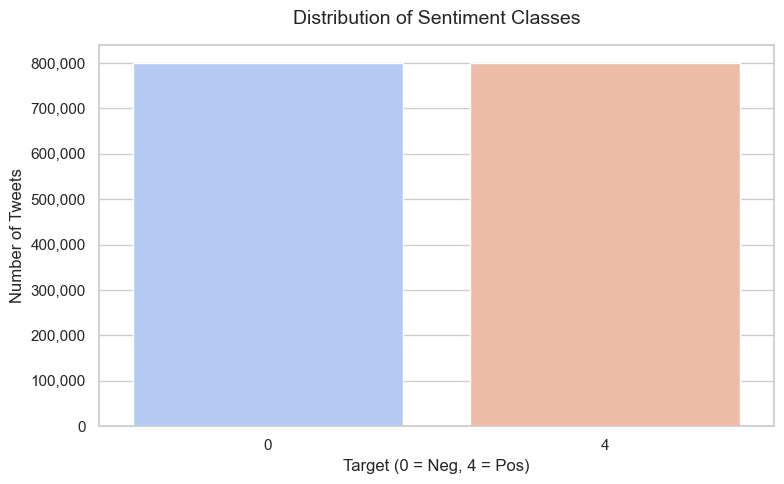

In [ ]:
# 0 = negative, 2 = neutral, 4 = positive
# The training set typically only contains 0 and 4, but we must verify.
target_counts = df['target'].value_counts().sort_index()
    
print("Exact Target Counts:")
for val, count in target_counts.items():
    label = "Negative" if val == 0 else "Neutral" if val == 2 else "Positive"
    print(f"[{val}] {label}: {count:,} ({count/len(df)*100:.2f}%)")
        
plt.figure(figsize=(8, 5))
ax = sns.barplot(x=target_counts.index, y=target_counts.values, palette="coolwarm")
plt.title('Distribution of Sentiment Classes', fontsize=14, pad=15)
plt.xlabel('Target (0 = Neg, 4 = Pos)', fontsize=12)
plt.ylabel('Number of Tweets', fontsize=12)
    
# Add commas to y-axis ticks
ax.get_yaxis().set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,}".format(int(x))))
    
plt.tight_layout()


## Text Metadata Analysis

In [17]:
# Calculate character count and word count
df['char_count'] = df['text'].apply(len)
df['word_count'] = df['text'].apply(lambda x: len(str(x).split()))
df['avg_word_length'] = df['char_count'] / df['word_count']
    
print("Summary Statistics for Word Count:")
print(df['word_count'].describe().round(2))
    
print("\nSummary Statistics for Character Count:")
print(df['char_count'].describe().round(2))

Summary Statistics for Word Count:
count    1600000.00
mean          13.18
std            6.96
min            1.00
25%            7.00
50%           12.00
75%           19.00
max           64.00
Name: word_count, dtype: float64

Summary Statistics for Character Count:
count    1600000.00
mean          74.09
std           36.44
min            6.00
25%           44.00
50%           69.00
75%          104.00
max          374.00
Name: char_count, dtype: float64


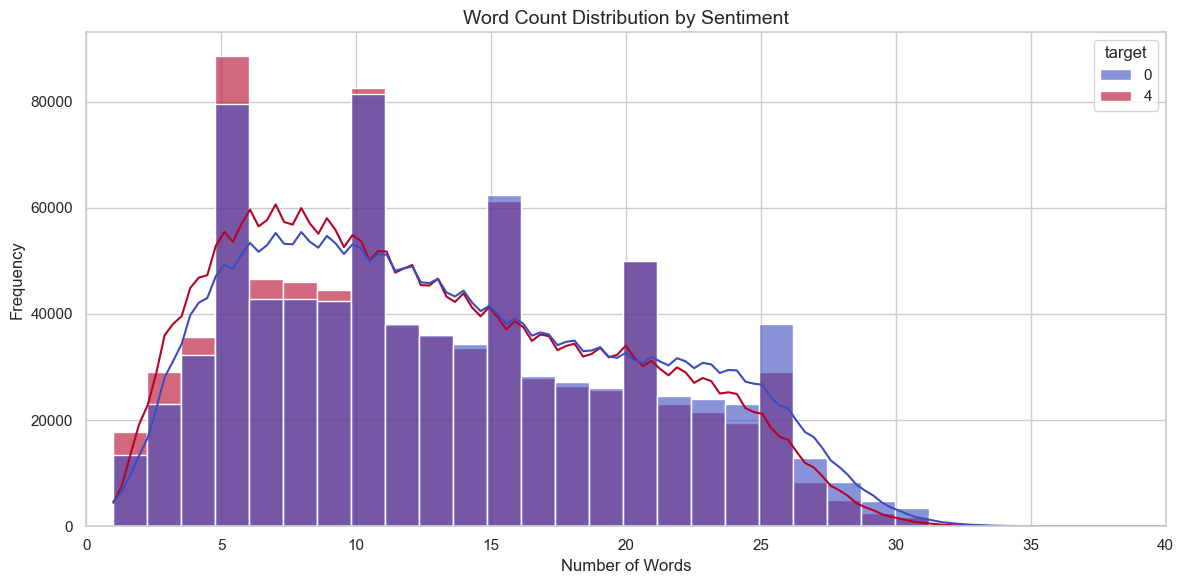

In [18]:
# Plotting Word Count Distribution by Sentiment
plt.figure(figsize=(12, 6))
sns.histplot(data=df, x='word_count', hue='target', bins=50, kde=True, palette='coolwarm', alpha=0.6)
plt.title('Word Count Distribution by Sentiment', fontsize=14)
plt.xlabel('Number of Words', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.xlim(0, 40) # Capping x-axis to zoom in on the bulk of the data
plt.tight_layout()    

In [ ]:
# 99th Percentile Calculation (Crucial for Transformer max_length)
p99 = np.percentile(df['word_count'], 99)
p99

28.0

Architectural Insight: 99% of tweets have 28 words or fewer.
We should set our DistilBERT tokenizer max_length to roughly 33 to capture edge cases without wasting compute.

## Temporal Analysis

When do people tweet?

In [26]:
# Date format: Sat May 16 23:58:44 UTC 2009
cleaned_dates = df['date'].str.replace(' PDT', '').str.replace(' UTC', '')

# We take a sample of 100k rows for temporal analysis to keep EDA fast
sample_df = df.sample(100000, random_state=42).copy()
sample_df['parsed_date'] = pd.to_datetime(cleaned_dates.loc[sample_df.index], format='%a %b %d %H:%M:%S %Y', errors='coerce')
    
sample_df = sample_df.dropna(subset=['parsed_date'])
sample_df['day_of_week'] = sample_df['parsed_date'].dt.day_name()
sample_df['hour_of_day'] = sample_df['parsed_date'].dt.hour

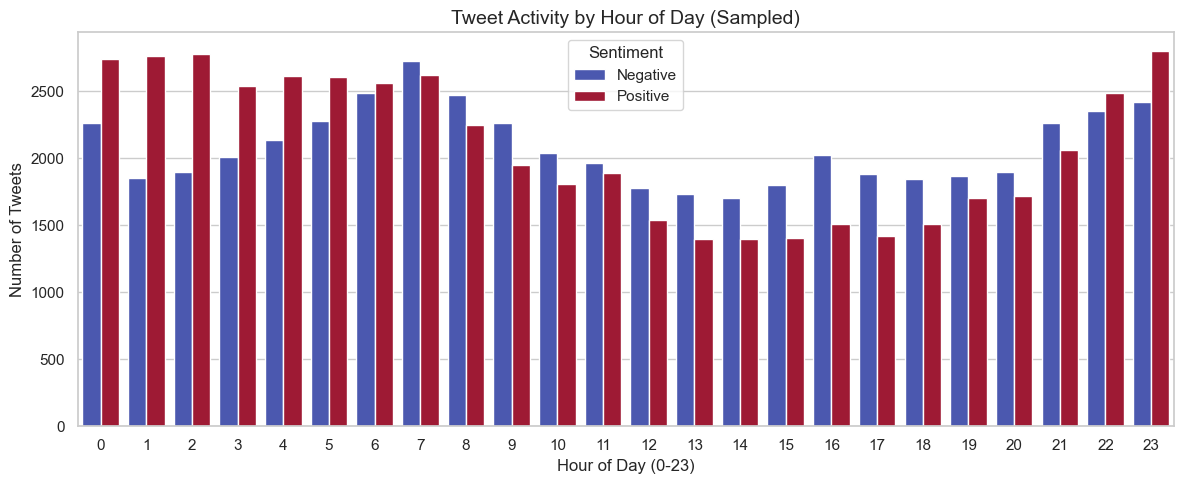

In [27]:
# Plot tweets by hour of day
plt.figure(figsize=(12, 5))
sns.countplot(data=sample_df, x='hour_of_day', hue='target', palette='coolwarm')
plt.title('Tweet Activity by Hour of Day (Sampled)', fontsize=14)
plt.xlabel('Hour of Day (0-23)', fontsize=12)
plt.ylabel('Number of Tweets', fontsize=12)
plt.legend(title='Sentiment', labels=['Negative', 'Positive'])
    
plt.tight_layout()

## Analyze Users

Total Unique Users: 659,775
Average Tweets per User: 2.43

Top 10 Most Active Users:
user
lost_dog           549
webwoke            345
tweetpet           310
SallytheShizzle    281
VioletsCRUK        279
mcraddictal        276
tsarnick           248
what_bugs_u        246
Karen230683        238
DarkPiano          236
Name: count, dtype: int64


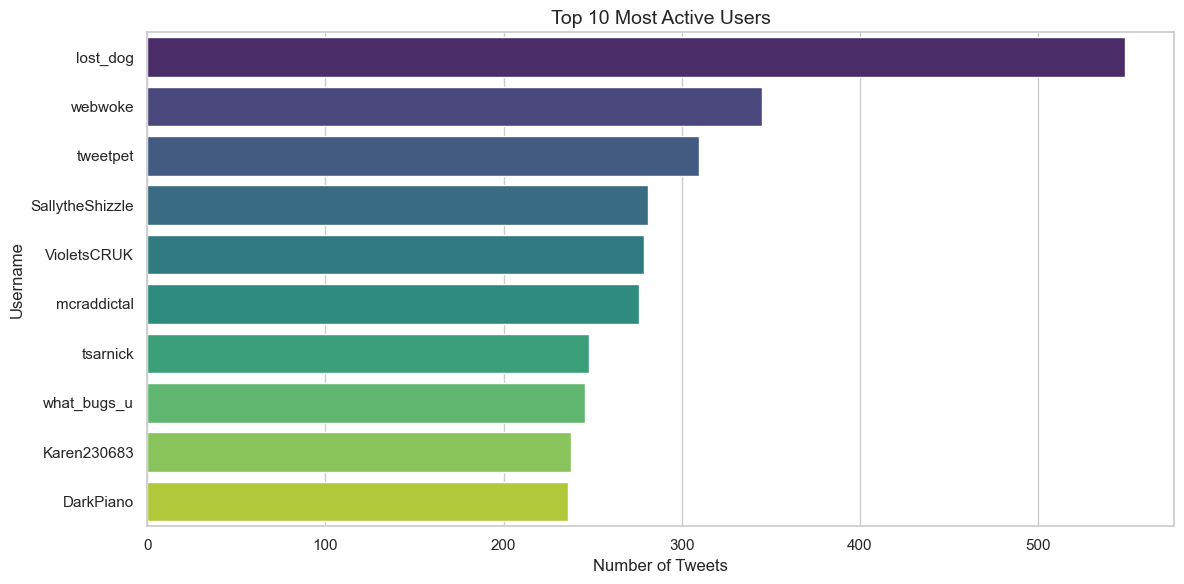

In [28]:
unique_users = df['user'].nunique()
print(f"Total Unique Users: {unique_users:,}")
print(f"Average Tweets per User: {len(df) / unique_users:.2f}")
    
top_users = df['user'].value_counts().head(10)
print("\nTop 10 Most Active Users:")
print(top_users)
    
plt.figure(figsize=(12, 6))
sns.barplot(y=top_users.index, x=top_users.values, palette='viridis')
plt.title('Top 10 Most Active Users', fontsize=14)
plt.xlabel('Number of Tweets')
plt.ylabel('Username')
    
plt.tight_layout()

# N-grams Analysis
Lexical and N-Gram Analysis (Positive vs Negative)

In [32]:
# Extract top bigrams for Negative tweeks (sample 800000 rows)
neg_tweets = df[df['target'] == 0]['text']
pos_tweets = df[df['target'] == 4]['text']

def get_top_n_bigrams(corpus, n=10):
    # We use english stop words to filter out "is the", "of a", etc.
    vec = CountVectorizer(ngram_range=(2, 2), stop_words='english').fit(corpus)
    bag_of_words = vec.transform(corpus)
    sum_words = bag_of_words.sum(axis=0) 
    words_freq = [(word, sum_words[0, idx]) for word, idx in vec.vocabulary_.items()]
    words_freq =sorted(words_freq, key = lambda x: x[1], reverse=True)
    return words_freq[:n]

top_neg_bigrams = get_top_n_bigrams(neg_tweets, 10)
top_pos_bigrams = get_top_n_bigrams(pos_tweets, 10)

print("\nTop 5 Negative Bigrams:")
for word, freq in top_neg_bigrams[:5]:
    print(f"  '{word}': {freq}")
        
print("\nTop 5 Positive Bigrams:")
for word, freq in top_pos_bigrams[:5]:
    print(f"  '{word}': {freq}")



Top 5 Negative Bigrams:
  'twitpic com': 6331
  'http twitpic': 6284
  'just got': 5548
  'feel like': 5138
  'don know': 4633

Top 5 Positive Bigrams:
  'twitpic com': 13605
  'http twitpic': 13488
  'bit ly': 9201
  'http bit': 9154
  'good morning': 8228


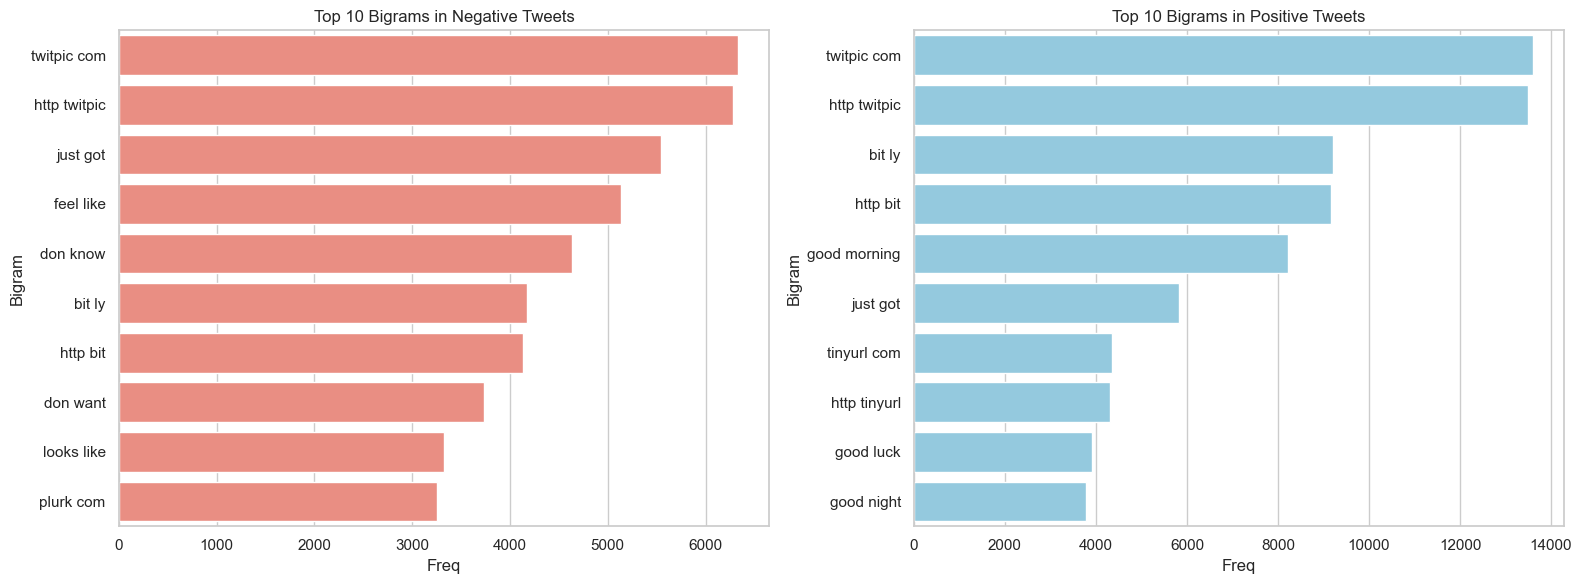

In [33]:
# Plotting Bigrams
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
neg_df = pd.DataFrame(top_neg_bigrams, columns=['Bigram', 'Freq'])
sns.barplot(data=neg_df, x='Freq', y='Bigram', ax=axes[0], color='salmon')
axes[0].set_title('Top 10 Bigrams in Negative Tweets')
    
pos_df = pd.DataFrame(top_pos_bigrams, columns=['Bigram', 'Freq'])
sns.barplot(data=pos_df, x='Freq', y='Bigram', ax=axes[1], color='skyblue')
axes[1].set_title('Top 10 Bigrams in Positive Tweets')
    
plt.tight_layout()